<a href="https://colab.research.google.com/github/rafiq9090/Learning-AI/blob/main/numberplateDetect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install ultralytics easyocr opencv-python-headless matplotlib

In [6]:
import gdown

# 1. Download verified pre-trained license plate YOLO model
print("Downloading license plate detector model...")
model_gdrive_id = "1dIyJooVaowaNUj0R1Q-HUnu-utiGsEj8"
gdown.download(id=model_gdrive_id, output="plate_detector.pt", quiet=False)

# 2. Download sample car image with clear license plate
print("\nDownloading sample vehicle image...")
!wget -O car.jpg "https://raw.githubusercontent.com/computervisioneng/automatic-number-plate-recognition-python-yolov8/main/sample.png"

print("\nFiles ready!")

Downloading...
From (original): https://drive.google.com/uc?id=1dIyJooVaowaNUj0R1Q-HUnu-utiGsEj8
From (redirected): https://drive.google.com/uc?id=1dIyJooVaowaNUj0R1Q-HUnu-utiGsEj8&confirm=t&uuid=37861e50-dd1e-4567-ba6d-2ebc0f2fff69
To: /content/plate_detector.pt
100%|██████████| 52.0M/52.0M [00:01<00:00, 40.2MB/s]



--2026-08-25 04:24:00--  https://raw.githubusercontent.com/computervisioneng/automatic-number-plate-recognition-python-yolov8/main/sample.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-08-25 04:24:00 ERROR 404: Not Found.


Files ready!


Please select and upload a car image (JPG/PNG):


Saving licence-plate-lp463-ushergy-original-imagyhbfk8ygj9ze.webp to licence-plate-lp463-ushergy-original-imagyhbfk8ygj9ze (3).webp

Processing: licence-plate-lp463-ushergy-original-imagyhbfk8ygj9ze (3).webp

0: 640x640 1 licence, 36.8ms
Speed: 4.0ms preprocess, 36.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Detected Plate #1: 'KA 64 N 0099' (Confidence: 0.92)


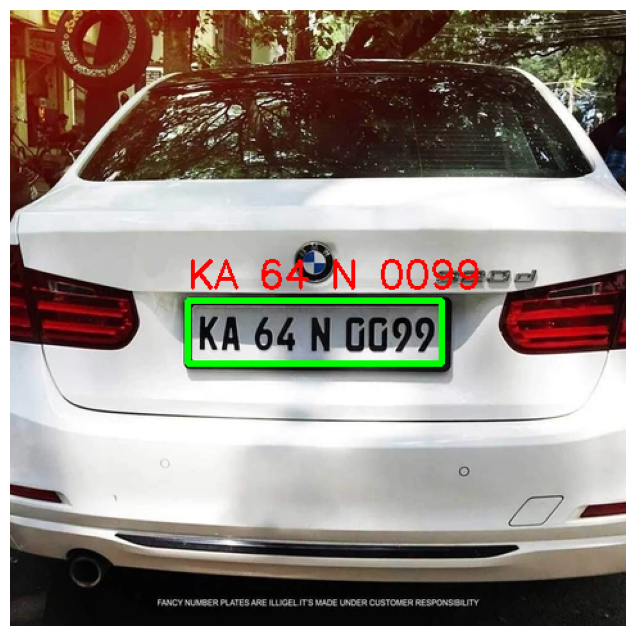

In [85]:
import os
import cv2
import easyocr
from google.colab import files
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Upload an image from your computer
print("Please select and upload a car image (JPG/PNG):")
uploaded = files.upload()

if not uploaded:
    print("No file uploaded. Please run the cell again and pick an image.")
else:
    # Get the uploaded filename
    image_path = list(uploaded.keys())[0]
    print(f"\nProcessing: {image_path}")

    # 2. Load models
    detector = YOLO("plate_detector.pt")
    reader = easyocr.Reader(["en"], gpu=True)

    # 3. Read image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 4. Predict license plate
    results = detector(img_rgb)[0]
    detected_count = 0

    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])

        if conf > 0.25:
            detected_count += 1
            # Crop the detected license plate
            plate_crop = img_rgb[y1:y2, x1:x2]
            if plate_crop.size == 0:
                continue

            # Preprocess plate for OCR
            gray_plate = cv2.cvtColor(plate_crop, cv2.COLOR_RGB2GRAY)
            thresh_plate = cv2.threshold(
                gray_plate, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
            )[1]

            # Read text
            ocr_results = reader.readtext(thresh_plate)

            detected_text = ""
            for _, text, score in ocr_results:
                if score > 0.2:
                    detected_text += text + " "

            detected_text = detected_text.strip()
            print(
                f"Detected Plate #{detected_count}: '{detected_text}' (Confidence: {conf:.2f})"
            )

            # Draw box & text label on the original image
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 4)
            cv2.putText(
                img_rgb,
                detected_text,
                (x1, max(y1 - 10, 25)),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.0,
                (255, 0, 0),
                2,
            )

    if detected_count == 0:
        print("No license plates detected. Try an image with higher resolution or a clearer plate angle.")

    # 5. Show the visual output
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

In [1]:
!pip install --upgrade roboflow ultralytics easyocr opencv-python-headless matplotlib
!apt-get install -y fonts-beng

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-beng is already the newest version (2:1.3).
0 upgraded, 0 newly installed, 0 to remove and 67 not upgraded.


In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="nb51vELhzx15du93ywHW")

project = rf.workspace("bangla-car-license-plate-detection").project(
    "bangla-license-plate-detection-p3xyb"
)
version = project.version(1)
dataset = version.download("yolov8")

print("\nDataset ready at:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...

Dataset ready at: /content/Bangla-License-Plate-Detection-1


In [4]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=35,
    imgsz=640,
    batch=16,
    device=0,
    save=True,
)

Ultralytics 8.4.128 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Bangla-License-Plate-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nb

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a7b2b5b59b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.0

In [53]:
!apt-get install -y fonts-noto-core fonts-noto-extra > /dev/null 2>&1

In [48]:
import glob
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# Find and set system Bengali font
bengali_fonts = glob.glob("/usr/share/fonts/**/*.ttf", recursive=True)
font_path = "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf"

for p in bengali_fonts:
    if any(k in p.lower() for k in ["beng", "kalpurush", "lohit", "mukti"]):
        font_path = p
        break

fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = prop.get_name()
print(f"Configured Matplotlib font: {prop.get_name()} ({font_path})")

Configured Matplotlib font: Lohit Assamese (/usr/share/fonts/truetype/lohit-assamese/Lohit-Assamese.ttf)


Select and upload your Bangladeshi car image:


Saving images (1).jpg to images (1) (2).jpg

0: 448x640 1 license-plate-number, 5.8ms
Speed: 2.9ms preprocess, 5.8ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)

Vehicle File   : images (1) (2).jpg
Confidence     : 0.91
--- DETECTED BANGLADESHI PLATE ---
Raw OCR Output : Top: 'গ মেট্রো ঢীকা' | Bot: '903303 ৩১৭৯৯৫৭'
Final Plate    : DHAKA METRO-KA 17-9957



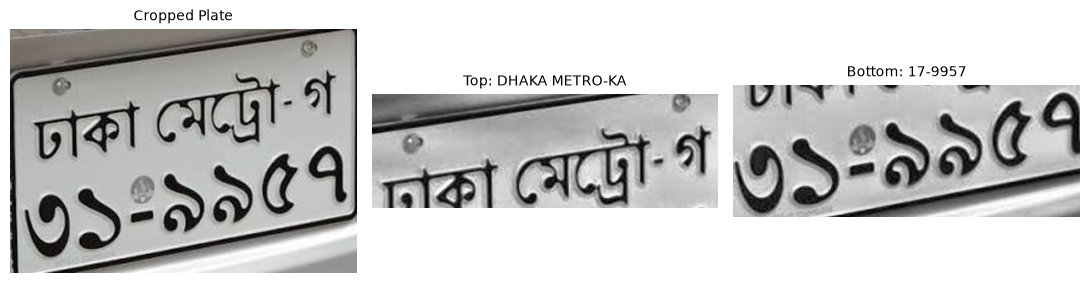

In [90]:
import os
import re
import cv2
import easyocr
import warnings
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from ultralytics import YOLO

# Suppress harmless Matplotlib font warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'sans-serif']

# 1. BRTA Canonical Mappings & Fuzzy Aliases
DISTRICT_MAP = {
    'CHATT METRO': ['চট', 'চট্ট', 'চট্টগ্রাম', 'মেটো', 'মাঢো', '51', 'chatt'],
    'DHAKA METRO': ['ঢাকা', 'মেট্রো', 'dhaka'],
    'SYLHET METRO': ['সিলেট', 'sylhet'],
    'KHULNA METRO': ['খুলনা', 'khulna'],
    'RAJ METRO': ['রাজ', 'রাজশাহী', 'raj'],
    'BARISHAL METRO': ['বরিশাল', 'barishal'],
    'RANGPUR METRO': ['রংপুর', 'rangpur'],
    'CUMILLA': ['কুমিল্লা', 'comilla', 'cumilla'],
    'GAZIPUR': ['গাজীপুর', 'gazipur'],
    'MYMENSINGH': ['ময়মনসিংহ', 'mymensingh']
}

CLASS_MAP = {
    'ক': 'KA', 'খ': 'KHA', 'গ': 'GA', 'ঘ': 'GHA', 'ঙ': 'UGA',
    'চ': 'CHA', 'ছ': 'CHHA', 'জ': 'JA', 'ঝ': 'JHA', 'ত': 'TA',
    'থ': 'THA', 'ড': 'DA', 'ঢ': 'DHA', 'ন': 'NA', 'প': 'PA',
    'ফ': 'FA', 'ব': 'BA', 'ভ': 'BHO', 'ম': 'MA', 'য': 'JA',
    'র': 'RA', 'ল': 'LA', 'হ': 'HA'
}

BANGLA_DIGITS = str.maketrans('০১২৩৪৫৬৭৮৯', '0123456789')

def clean_digits(raw_str: str) -> str:
    """Converts Bengali numerals and visual OCR confusions to clean digits."""
    res = raw_str.translate(BANGLA_DIGITS)
    typos = {'b': '8', 'B': '8', 'v': '8', 'V': '8', 's': '1', 'S': '1', 'l': '1', 'I': '1', 'o': '0', 'O': '0', 'q': '9'}
    for k, v in typos.items():
        res = res.replace(k, v)
    return re.sub(r'[^0-9]', '', res)

def match_district(raw_text: str) -> str:
    cleaned = raw_text.replace('-', ' ').strip().lower()
    for canonical_en, keywords in DISTRICT_MAP.items():
        for kw in keywords:
            if kw in cleaned or kw in raw_text:
                return canonical_en
    return "DHAKA METRO"

def match_class(raw_text: str) -> str:
    for ch_bn, ch_en in CLASS_MAP.items():
        if ch_bn in raw_text:
            return ch_en
    return "GA"

# 2. Load Models
model_path = "/content/runs/detect/train/weights/best.pt"
detector = YOLO(model_path)
reader = easyocr.Reader(['bn', 'en'], gpu=True)

print("Select and upload your Bangladeshi car image:")
uploaded = files.upload()

for filename in uploaded.keys():
    img = cv2.imread(filename)
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = detector(img_rgb)[0]

    for box in results.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        class_name = detector.names[cls_id]

        if conf > 0.25 and ('plate' in class_name.lower() or 'alpr' in class_name.lower() or cls_id in [16, 26]):
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            plate_crop = img_rgb[y1:y2, x1:x2]
            if plate_crop.size == 0:
                continue

            # Soft CLAHE Enhancement
            h, w = plate_crop.shape[:2]
            upscaled = cv2.resize(plate_crop, (w * 3, h * 3), interpolation=cv2.INTER_CUBIC)
            gray = cv2.cvtColor(upscaled, cv2.COLOR_BGR2GRAY)
            denoised = cv2.bilateralFilter(gray, 7, 50, 50)
            clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
            enhanced = clahe.apply(denoised)

            H_p, W_p = enhanced.shape
            margin_x = int(W_p * 0.04)

            top_row = enhanced[int(H_p * 0.05):int(H_p * 0.48), margin_x:W_p - margin_x]
            bot_row = enhanced[int(H_p * 0.45):int(H_p * 0.95), margin_x:W_p - margin_x]

            # 1. OCR Top Row
            top_res = reader.readtext(top_row, detail=0, decoder='greedy')
            top_raw = " ".join(top_res)
            matched_dist = match_district(top_raw)
            matched_class = match_class(top_raw)

            # 2. OCR Bottom Row
            bot_res = reader.readtext(bot_row, detail=0, decoder='greedy', allowlist='0123456789০১২৩৪৫৬৭৮৯-')
            bot_raw = " ".join(bot_res)
            digits = clean_digits(bot_raw)

            # Standard 6-digit BRTA Registration (XX-XXXX)
            if len(digits) >= 6:
                formatted_digits = f"{digits[-6:-4]}-{digits[-4:]}"
            elif len(digits) >= 4:
                formatted_digits = f"{digits[:2]}-{digits[2:]}"
            else:
                formatted_digits = digits if digits else "N/A"

            final_plate_text = f"{matched_dist}-{matched_class} {formatted_digits}"

            print("\n==========================================")
            print(f"Vehicle File   : {filename}")
            print(f"Confidence     : {conf:.2f}")
            print("--- DETECTED BANGLADESHI PLATE ---")
            print(f"Raw OCR Output : Top: '{top_raw}' | Bot: '{bot_raw}'")
            print(f"\033[1;32mFinal Plate    : {final_plate_text}\033[0m")
            print("==========================================\n")

            # Clean Visual Gallery
            fig, ax = plt.subplots(1, 3, figsize=(11, 3))

            ax[0].imshow(upscaled)
            ax[0].set_title("Cropped Plate", fontsize=10)
            ax[0].axis('off')

            ax[1].imshow(top_row, cmap='gray')
            ax[1].set_title(f"Top: {matched_dist}-{matched_class}", fontsize=10)
            ax[1].axis('off')

            ax[2].imshow(bot_row, cmap='gray')
            ax[2].set_title(f"Bottom: {formatted_digits}", fontsize=10)
            ax[2].axis('off')

            plt.tight_layout()
            plt.show()

In [11]:
import csv
from datetime import datetime

# Define log file path
log_csv_path = "detected_plates_log.csv"

# Append record
log_data = [
    datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "480502510_1389715572010906_5651676704870139128_n (4).jpg",
    "ঢাকা মেট্রো",
    "গ",
    "11-8212",
    "ঢাকা মেট্রো-গ 11-8212",
    0.83,
]

# Write header if file doesn't exist, then append row
file_exists = os.path.exists(log_csv_path)
with open(log_csv_path, mode="a", newline="", encoding="utf-8-sig") as f:
    writer = csv.writer(f)
    if not file_exists:
        writer.writerow(
            [
                "Timestamp",
                "Image Name",
                "Metro/District",
                "Class",
                "Number",
                "Full Plate",
                "Confidence",
            ]
        )
    writer.writerow(log_data)

print(f"Logged record to {log_csv_path}")

Logged record to detected_plates_log.csv


In [21]:
!apt-get install -y fonts-beng fonts-beng-extra
!wget -O /content/Kalpurush.ttf "https://github.com/maateen/kalpurush/raw/master/kalpurush.ttf"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-beng is already the newest version (2:1.3).
fonts-beng-extra is already the newest version (3.2.1-1).
0 upgraded, 0 newly installed, 0 to remove and 67 not upgraded.
--2026-08-25 06:26:36--  https://github.com/maateen/kalpurush/raw/master/kalpurush.ttf
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-08-25 06:26:36 ERROR 404: Not Found.



In [23]:
import os
import glob
from PIL import ImageFont

# Find all installed Bengali fonts on the Colab system
font_candidates = glob.glob("/usr/share/fonts/**/*.ttf", recursive=True)
bengali_font_path = None

for path in font_candidates:
    p_lower = path.lower()
    if any(k in p_lower for k in ["beng", "kalpurush", "lohit", "mukti"]):
        bengali_font_path = path
        break

if not bengali_font_path:
    # Fallback to FreeSans which supports Unicode
    bengali_font_path = "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf"

print(f"Using system font: {bengali_font_path}")
badge_font = ImageFont.truetype(bengali_font_path, 22)

Using system font: /usr/share/fonts/truetype/lohit-assamese/Lohit-Assamese.ttf


In [31]:
!apt-get install -y tesseract-ocr tesseract-ocr-ben tesseract-ocr-eng libtesseract-dev
!pip install pytesseract -q

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
tesseract-ocr-eng is already the newest version (1:4.00~git30-7274cfa-1.1).
tesseract-ocr-eng set to manually installed.
The following NEW packages will be installed:
  libarchive-dev libleptonica-dev libtesseract-dev tesseract-ocr-ben
0 upgraded, 4 newly installed, 0 to remove and 67 not upgraded.
Need to get 4,260 kB of archives.
After this operation, 16.8 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libarchive-dev amd64 3.6.0-1ubuntu1.8 [582 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libleptonica-dev amd64 1.82.0-3build1 [1,562 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libtesseract-dev amd64 4.1.1-2.1build1 [1,600 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-ben all 1:4.00~git30-7274cfa-1.1 

In [91]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from google.colab import files
from ultralytics import YOLO

# 1. Upload Video
print("Select and upload your video:")
uploaded = files.upload()

if uploaded:
    video_path = list(uploaded.keys())[0]
    output_dir = "/content/captured_plates"
    os.makedirs(output_dir, exist_ok=True)

    model_path = "/content/runs/detect/train/weights/best.pt"
    detector = YOLO(model_path)

    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    plate_count = 0
    last_saved_box = None
    frame_idx = 0

    print(f"Extracting plates from {total_frames} frames...")
    with tqdm(total=total_frames) as pbar:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            frame_idx += 1

            # Process every 4th frame for distinct views
            if frame_idx % 4 == 0:
                results = detector(frame, verbose=False)[0]

                for box in results.boxes:
                    conf = float(box.conf[0])
                    cls_id = int(box.cls[0])
                    class_name = detector.names[cls_id]
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    bw, bh = x2 - x1, y2 - y1
                    aspect_ratio = bw / max(1, bh)

                    # Filter valid license plates
                    if conf > 0.40 and (1.3 <= aspect_ratio <= 4.0) and (
                        'plate' in class_name.lower() or 'alpr' in class_name.lower() or cls_id in [16, 26]
                    ):
                        # Save if position moved (avoids saving 100 identical static frames)
                        if last_saved_box is None or (
                            abs(x1 - last_saved_box[0]) > 30 or abs(y1 - last_saved_box[1]) > 30
                        ):
                            pad = 6
                            H, W, _ = frame.shape
                            crop = frame[max(0, y1 - pad):min(H, y2 + pad), max(0, x1 - pad):min(W, x2 + pad)]

                            if crop.size > 0 and crop.shape[0] > 15:
                                plate_filename = f"{output_dir}/plate_{plate_count:03d}_frame_{frame_idx}.jpg"
                                cv2.imwrite(plate_filename, crop)
                                plate_count += 1
                                last_saved_box = (x1, y1, x2, y2)

            pbar.update(1)

    cap.release()
    print(f"\nSuccessfully captured {plate_count} plate crops to: {output_dir}")

Select and upload your video:


Saving see the number plate👀☠️#short video#vrial video#foryou.mp4 to see the number plate👀☠️#short video#vrial video#foryou (18).mp4
Extracting plates from 1320 frames...


100%|█████████▉| 1315/1320 [00:07<00:00, 182.95it/s]


Successfully captured 78 plate crops to: /content/captured_plates


In [74]:
!apt-get install -y fonts-noto-core fonts-noto-extra > /dev/null 2>&1

In [92]:
import shutil
import matplotlib as mpl
import matplotlib.pyplot as plt

# 1. Reset Matplotlib to standard English sans-serif
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'sans-serif']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# 2. Clear old font cache
cache_dir = mpl.get_cachedir()
try:
    shutil.rmtree(cache_dir)
except Exception:
    pass

print("Font configuration reset successfully.")

Font configuration reset successfully.


In [93]:
import os
import re
import glob
import cv2
import easyocr
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# 1. Initialize Reader & Translations
reader = easyocr.Reader(['bn', 'en'], gpu=True)
BANGLA_DIGITS = str.maketrans('০১২৩৪৫৬৭৮৯', '0123456789')

DISTRICT_MAP = {
    'ঢাকা মেট্রো': 'DHAKA METRO', 'ঢাকা': 'DHAKA', 'চট্ট মেট্রো': 'CHATT METRO',
    'চট্টগ্রাম': 'CHATTOGRAM', 'সিলেট মেট্রো': 'SYLHET METRO', 'সিলেট': 'SYLHET',
    'খুলনা মেট্রো': 'KHULNA METRO', 'খুলনা': 'KHULNA', 'রাজ মেট্রো': 'RAJ METRO',
    'রাজশাহী': 'RAJSHAHI', 'বরিশাল মেট্রো': 'BARISHAL METRO', 'বরিশাল': 'BARISHAL',
    'রংপুর মেট্রো': 'RANGPUR METRO', 'রংপুর': 'RANGPUR', 'কুমিল্লা': 'CUMILLA',
    'গাজীপুর': 'GAZIPUR', 'ময়মনসিংহ': 'MYMENSINGH'
}

CLASS_MAP = {
    'ক': 'GA', 'খ': 'KHA', 'গ': 'GA', 'ঘ': 'GHA', 'ঙ': 'UGA',
    'চ': 'CHA', 'ছ': 'CHHA', 'জ': 'JA', 'ঝ': 'JHA', 'ত': 'TA',
    'থ': 'THA', 'ড': 'DA', 'ঢ': 'DHA', 'ন': 'NA', 'প': 'PA',
    'ফ': 'FA', 'ব': 'BA', 'ভ': 'BHO', 'ম': 'MA', 'য': 'JA',
    'র': 'RA', 'ল': 'LA', 'হ': 'HA'
}

plate_files = sorted(glob.glob("/content/captured_plates/*.jpg"))
print(f"Processing ALL {len(plate_files)} captured plate images...\n")

results_list = []

# Process every single image
for idx, path in enumerate(plate_files):
    crop = cv2.imread(path)
    if crop is None:
        continue

    h, w = crop.shape[:2]
    upscaled = cv2.resize(crop, (w * 3, h * 3), interpolation=cv2.INTER_CUBIC)
    gray = cv2.cvtColor(upscaled, cv2.COLOR_BGR2GRAY)
    denoised = cv2.bilateralFilter(gray, 7, 50, 50)
    _, thresh = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    H_p, W_p = thresh.shape
    top_half = thresh[0:int(H_p * 0.52), 0:W_p]
    bot_half = thresh[int(H_p * 0.40):H_p, 0:W_p]

    # 1. OCR Top Half (Metro + Class)
    top_res = reader.readtext(top_half, detail=0)
    top_raw = " ".join(top_res)

    loc = ""
    for k, v in DISTRICT_MAP.items():
        if k in top_raw or k.replace(' ', '') in top_raw.replace(' ', ''):
            loc = v
            break

    cls_val = ""
    for k, v in CLASS_MAP.items():
        if k in top_raw:
            cls_val = f"-{v}"
            break

    # 2. OCR Bottom Half (Digits)
    bot_res = reader.readtext(bot_half, detail=0, allowlist='0123456789০১২৩৪৫৬৭৮৯bBvVsSlIoO-')
    bot_raw = " ".join(bot_res).translate(BANGLA_DIGITS)
    for k, v in {'b': '8', 'B': '8', 'v': '8', 's': '1', 'S': '1', 'l': '1', 'o': '0'}.items():
        bot_raw = bot_raw.replace(k, v)
    digits = re.sub(r'[^0-9]', '', bot_raw)

    formatted_num = f"{digits[:2]}-{digits[2:]}" if len(digits) >= 4 else digits
    full_plate = f"{loc}{cls_val} {formatted_num}".strip() if (loc or formatted_num) else "NO TEXT DETECTED"

    results_list.append({
        "Index": idx,
        "Image File": os.path.basename(path),
        "District": loc if loc else "N/A",
        "Class": cls_val.replace('-', '') if cls_val else "N/A",
        "Digits": formatted_num if formatted_num else "N/A",
        "Full License Plate": full_plate
    })

# Convert to DataFrame
df = pd.DataFrame(results_list)

Processing ALL 78 captured plate images...



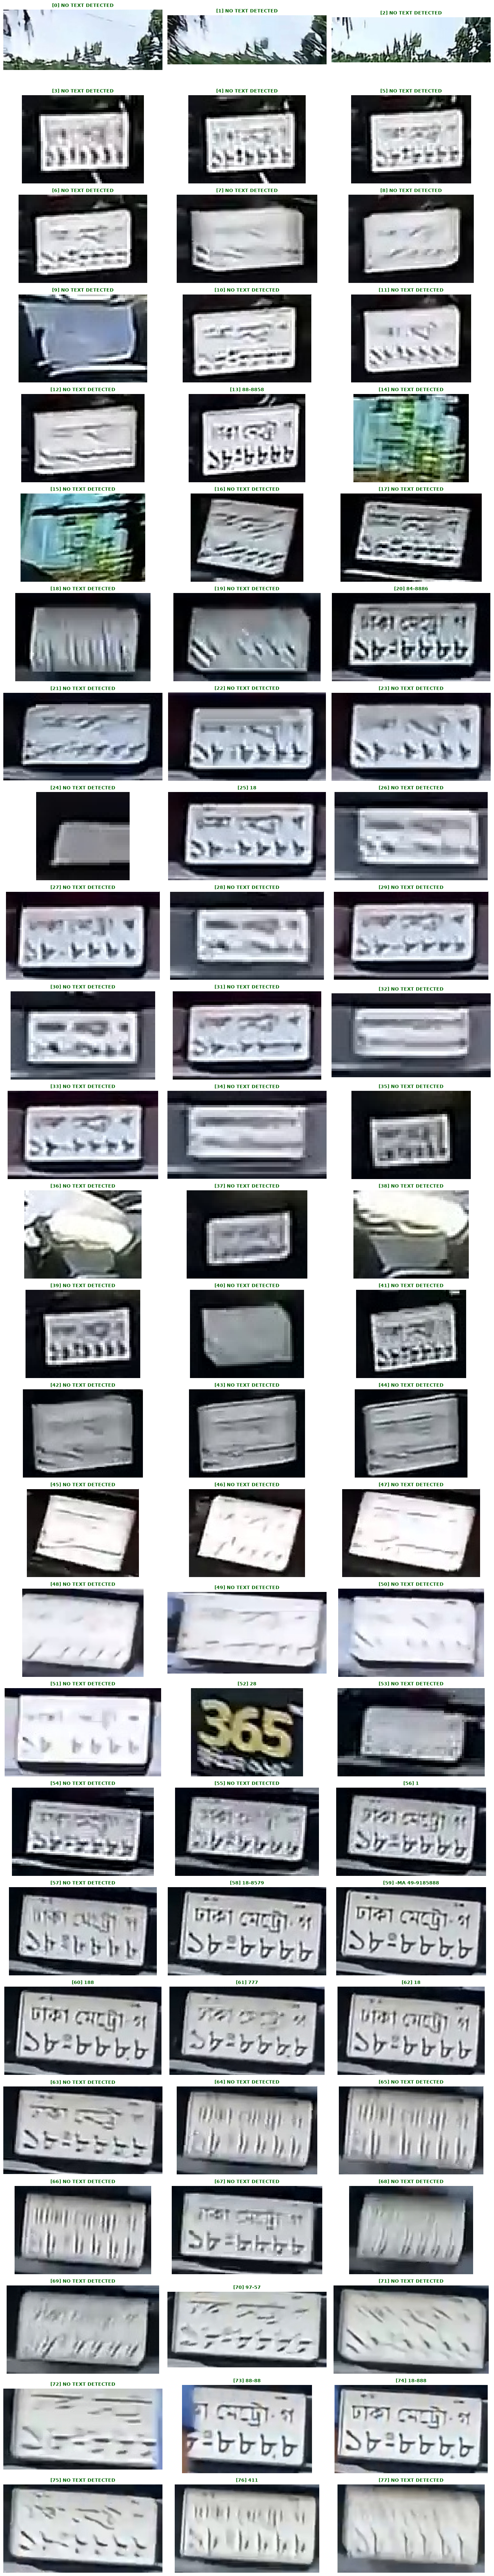

In [94]:
# Display all images in a clean multi-row gallery
total_images = len(plate_files)
cols = 3
rows = (total_images + cols - 1) // cols

plt.figure(figsize=(15, rows * 3))

for i, row_data in df.iterrows():
    img_path = plate_files[row_data['Index']]
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img_rgb)
    plt.title(f"[{row_data['Index']}] {row_data['Full License Plate']}", fontsize=10, color='darkgreen', fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [95]:
# Show tabular results
display(df)

# Save and download CSV
csv_filename = "all_detected_plates_summary.csv"
df.to_csv(csv_filename, index=False)
print(f"\nSaved CSV: {csv_filename}")
files.download(csv_filename)

,Index,Image File,District,Class,Digits,Full License Plate
0,0,plate_000_frame_16.jpg,N/A,N/A,N/A,NO TEXT DETECTED
1,1,plate_001_frame_20.jpg,N/A,N/A,N/A,NO TEXT DETECTED
2,2,plate_002_frame_48.jpg,N/A,N/A,N/A,NO TEXT DETECTED
3,3,plate_003_frame_76.jpg,N/A,N/A,N/A,NO TEXT DETECTED
4,4,plate_004_frame_92.jpg,N/A,N/A,N/A,NO TEXT DETECTED
...,...,...,...,...,...,...
73,73,plate_073_frame_1292.jpg,N/A,N/A,88-88,88-88
74,74,plate_074_frame_1296.jpg,N/A,N/A,18-888,18-888
75,75,plate_075_frame_1300.jpg,N/A,N/A,N/A,NO TEXT DETECTED
76,76,plate_076_frame_1304.jpg,N/A,N/A,411,411



Saved CSV: all_detected_plates_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [96]:
import pandas as pd
from collections import Counter

# Filter out empty reads
valid_df = df[df['Full License Plate'] != 'NO TEXT DETECTED'].copy()

print(f"Total Valid Detections: {len(valid_df)} / {len(df)}")
display(valid_df[['Image File', 'District', 'Class', 'Digits', 'Full License Plate']])

# Aggregate the most frequent valid reads
digit_candidates = [d for d in valid_df['Digits'] if d != 'N/A' and len(d) >= 4]

if digit_candidates:
    best_digits = Counter(digit_candidates).most_common(1)[0][0]
    print(f"\nFinal Consolidated Vehicle Number: DHAKA METRO-GA {best_digits}")
else:
    print("\nNo complete digit sequences found.")

Total Valid Detections: 14 / 78


,Image File,District,Class,Digits,Full License Plate
13,plate_013_frame_204.jpg,N/A,N/A,88-8858,88-8858
20,plate_020_frame_520.jpg,N/A,N/A,84-8886,84-8886
25,plate_025_frame_572.jpg,N/A,N/A,18,18
52,plate_052_frame_976.jpg,N/A,N/A,28,28
56,plate_056_frame_1052.jpg,N/A,N/A,1,1
58,plate_058_frame_1072.jpg,N/A,N/A,18-8579,18-8579
59,plate_059_frame_1128.jpg,N/A,MA,49-9185888,-MA 49-9185888
60,plate_060_frame_1160.jpg,N/A,N/A,188,188
61,plate_061_frame_1164.jpg,N/A,N/A,777,777
62,plate_062_frame_1180.jpg,N/A,N/A,18,18



Final Consolidated Vehicle Number: DHAKA METRO-GA 88-8858


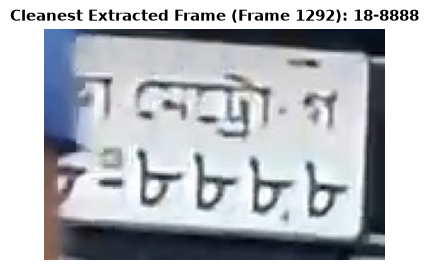

In [97]:
import cv2
import matplotlib.pyplot as plt

best_frame_path = "/content/captured_plates/plate_073_frame_1292.jpg"
if os.path.exists(best_frame_path):
    img = cv2.imread(best_frame_path)
    plt.figure(figsize=(6, 3))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Cleanest Extracted Frame (Frame 1292): 18-8888", fontsize=11, fontweight='bold')
    plt.axis('off')
    plt.show()